# What Drives Developers to Look for New Jobs?

## Motivation

As someone entering the tech field, I wanted to understand what factors influence whether developers stay in their jobs or start looking for new ones.

## Research Question

Does work environment (remote vs in-person) affect whether developers are actively looking for a new job?

## Data Source

This dataset comes from the Stack Overflow 2023 Developer Survey, which includes responses from over 80,000 developers worldwide.

In [ ]:
import pandas as pd

df = pd.read_csv('survey_results_public.csv')

df.head()

,ResponseId,Q120,MainBranch,Age,Employment,RemoteWork,CodingActivities,EdLevel,LearnCode,LearnCodeOnline,...,Frequency_1,Frequency_2,Frequency_3,TimeSearching,TimeAnswering,ProfessionalTech,Industry,SurveyLength,SurveyEase,ConvertedCompYearly
0,1,I agree,None of these,18-24 years old,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,I agree,I am a developer by profession,25-34 years old,"Employed, full-time",Remote,Hobby;Contribute to open-source projects;Boots...,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",Books / Physical media;Colleague;Friend or fam...,Formal documentation provided by the owner of ...,...,1-2 times a week,10+ times a week,Never,15-30 minutes a day,15-30 minutes a day,DevOps function;Microservices;Automated testin...,"Information Services, IT, Software Development...",Appropriate in length,Easy,285000.0
2,3,I agree,I am a developer by profession,45-54 years old,"Employed, full-time","Hybrid (some remote, some in-person)",Hobby;Professional development or self-paced l...,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",Books / Physical media;Colleague;On the job tr...,Formal documentation provided by the owner of ...,...,6-10 times a week,6-10 times a week,3-5 times a week,30-60 minutes a day,30-60 minutes a day,DevOps function;Microservices;Automated testin...,"Information Services, IT, Software Development...",Appropriate in length,Easy,250000.0
3,4,I agree,I am a developer by profession,25-34 years old,"Employed, full-time","Hybrid (some remote, some in-person)",Hobby,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",Colleague;Friend or family member;Other online...,Formal documentation provided by the owner of ...,...,1-2 times a week,10+ times a week,1-2 times a week,15-30 minutes a day,30-60 minutes a day,Automated testing;Continuous integration (CI) ...,NaN,Appropriate in length,Easy,156000.0
4,5,I agree,I am a developer by profession,25-34 years old,"Employed, full-time;Independent contractor, fr...",Remote,Hobby;Contribute to open-source projects;Profe...,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",Books / Physical media;Online Courses or Certi...,Formal documentation provided by the owner of ...,...,1-2 times a week,1-2 times a week,3-5 times a week,60-120 minutes a day,30-60 minutes a day,Microservices;Automated testing;Observability ...,Other,Appropriate in length,Neither easy nor difficult,23456.0


## Data Cleaning

For this analysis, I filtered the dataset to focus specifically on the ‘Employment’ and ‘RemoteWork’ columns, as they are directly related to my research question. I removed missing values to ensure accurate comparisons and created a new variable (‘looking_for_job’) to identify developers who are actively seeking new opportunities.

In [ ]:
df = df[['Employment', 'RemoteWork']].dropna()

In [ ]:
df['looking_for_job'] = df['Employment'].str.contains('looking', case=False)

In [ ]:
result = (df.groupby('RemoteWork')['looking_for_job'].mean() * 100).round(2)
result

,looking_for_job
RemoteWork,
"Hybrid (some remote, some in-person)",0.73
In-person,0.61
Remote,1.55


## Function

I created a reusable function to calculate job-seeking rates, allowing me to apply the same logic across different work environments without repeating code.


In [ ]:
def job_seeking_rate(series):
    return round(series.mean() * 100, 2)

## Analysis and Visualization

The chart below shows the percentage of developers actively looking for a new job across different work environments.

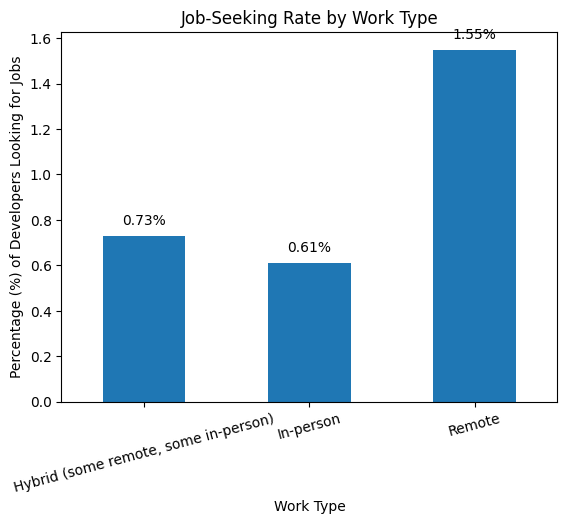

In [ ]:
import matplotlib.pyplot as plt

result = (df.groupby('RemoteWork')['looking_for_job'].mean() * 100).round(2)

result.plot(kind='bar')

plt.title('Job-Seeking Rate by Work Type')
plt.ylabel('Percentage (%) of Developers Looking for Jobs')
plt.xlabel('Work Type')
plt.xticks(rotation=15)

# Add value labels on top of bars
for i, v in enumerate(result):
    plt.text(i, v + 0.05, str(v) + '%', ha='center')

plt.show()

## Conclusion

Remote workers in this dataset show the highest job-seeking rate (1.55%), followed by hybrid (0.73%), while in-person workers show the lowest (0.61%). Although the differences are relatively small, the pattern suggests that remote work alone may not determine job satisfaction or retention. Other factors such as career growth, compensation, and workplace culture may play a larger role in influencing whether developers look for new opportunities.

This finding is interesting because remote work is often associated with better work-life balance, yet the data suggests it does not necessarily reduce job mobility. In fact, remote developers are more than twice as likely to be actively job-seeking compared to in-person developers.

For someone entering the tech field, this highlights the importance of evaluating roles based on long-term growth and stability—not just whether the position is remote.

